In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


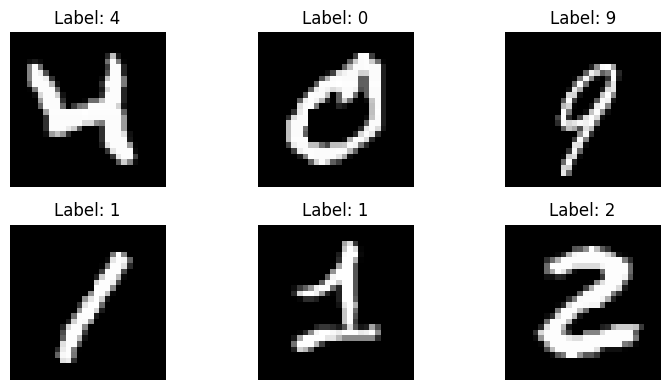

In [3]:
plt.figure(figsize=(8, 4))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(x_train[i + 20], cmap='gray')
    plt.title("Label: " + str(y_train[i + 20]))
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\USER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8919 - loss: 0.3878 - val_accuracy: 0.9424 - val_loss: 0.2082
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9469 - loss: 0.1849 - val_accuracy: 0.9548 - val_loss: 0.1615
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9583 - loss: 0.1392 - val_accuracy: 0.9603 - val_loss: 0.1422
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9671 - loss: 0.1103 - val_accuracy: 0.9656 - val_loss: 0.1173
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9732 - loss: 0.0900 - val_accuracy: 0.9660 - val_loss: 0.1104


In [11]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("\n========== MODEL RESULTS ==========")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy Percentage:", test_accuracy * 100, "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9687 - loss: 0.1064

========== MODEL RESULTS ==========
Test Loss: 0.10642706602811813
Test Accuracy: 0.9686999917030334
Test Accuracy Percentage: 96.86999917030334 %


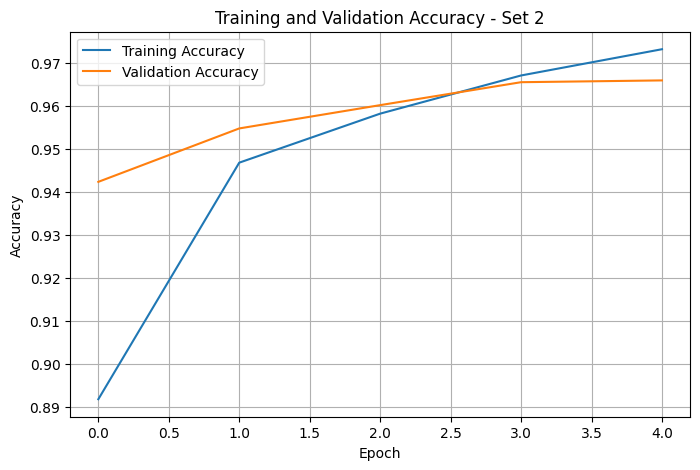

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy - Set 2')
plt.legend()
plt.grid()
plt.show()



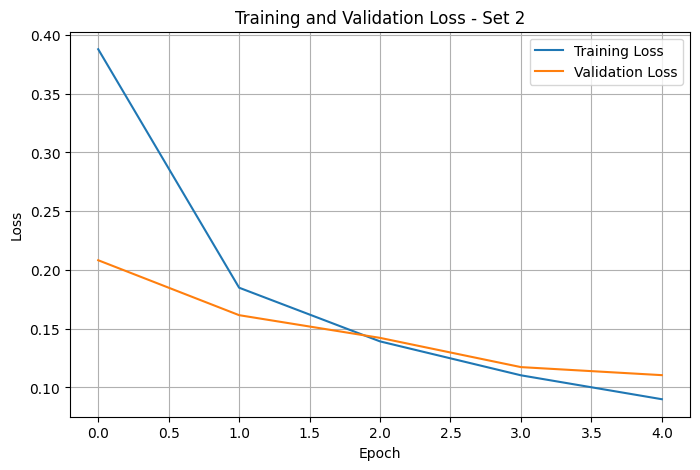

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss - Set 2')
plt.legend()
plt.grid()
plt.show()


In [14]:
predictions = model.predict(x_test[10:15])

predicted_labels = np.argmax(predictions, axis=1)

print("\n========== FIVE IMAGE PREDICTIONS ==========")

for i in range(5):
    print(
        "Image", i + 1,
        "| Actual =", y_test[i + 10],
        "| Predicted =", predicted_labels[i]
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step

========== FIVE IMAGE PREDICTIONS ==========
Image 1 | Actual = 0 | Predicted = 0
Image 2 | Actual = 6 | Predicted = 6
Image 3 | Actual = 9 | Predicted = 9
Image 4 | Actual = 0 | Predicted = 0
Image 5 | Actual = 1 | Predicted = 1


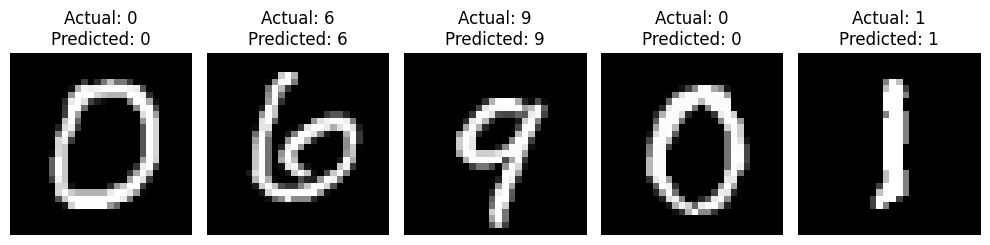

In [15]:
plt.figure(figsize=(10, 4))

for i in range(5):

    plt.subplot(1, 5, i + 1)

    plt.imshow(
        x_test[i + 10],
        cmap='gray'
    )

    plt.title(
        "Actual: " + str(y_test[i + 10]) +
        "\nPredicted: " + str(predicted_labels[i])
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [16]:
experiment_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [ ]:
experiment_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
experiment_history = experiment_model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8572 - loss: 0.4933 - val_accuracy: 0.9360 - val_loss: 0.2233
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9215 - loss: 0.2699 - val_accuracy: 0.9475 - val_loss: 0.1817
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9343 - loss: 0.2249 - val_accuracy: 0.9585 - val_loss: 0.1507
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9442 - loss: 0.1927 - val_accuracy: 0.9606 - val_loss: 0.1358
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9461 - loss: 0.1767 - val_accuracy: 0.9628 - val_loss: 0.1266


In [19]:
exp_loss, exp_accuracy = experiment_model.evaluate(
    x_test,
    y_test
)

print("\n========== EXPERIMENTAL MODEL RESULTS ==========")

print("Experimental Test Loss:", exp_loss)

print(
    "Experimental Test Accuracy:",
    exp_accuracy
)

print(
    "Experimental Accuracy Percentage:",
    exp_accuracy * 100,
    "%"
)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9626 - loss: 0.1247

========== EXPERIMENTAL MODEL RESULTS ==========
Experimental Test Loss: 0.12469293177127838
Experimental Test Accuracy: 0.9625999927520752
Experimental Accuracy Percentage: 96.25999927520752 %


In [20]:
print("\n========== FINAL COMPARISON ==========")

print(
    "Original Model Accuracy:",
    test_accuracy * 100,
    "%"
)

print(
    "Experimental Model Accuracy:",
    exp_accuracy * 100,
    "%"
)


========== FINAL COMPARISON ==========
Original Model Accuracy: 96.86999917030334 %
Experimental Model Accuracy: 96.25999927520752 %


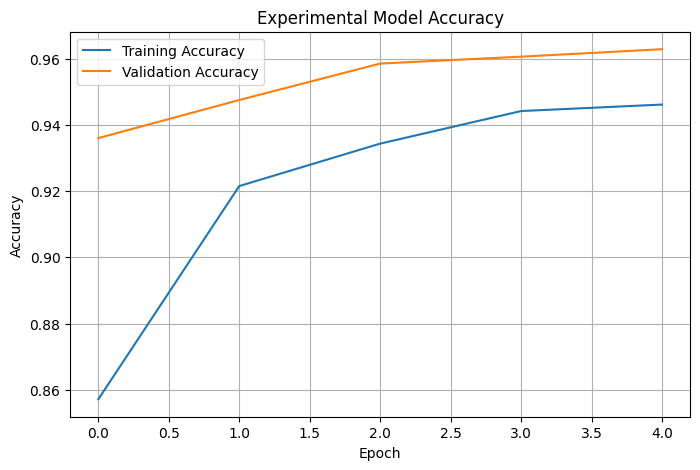

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    experiment_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    experiment_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Experimental Model Accuracy')
plt.legend()
plt.grid()
plt.show()

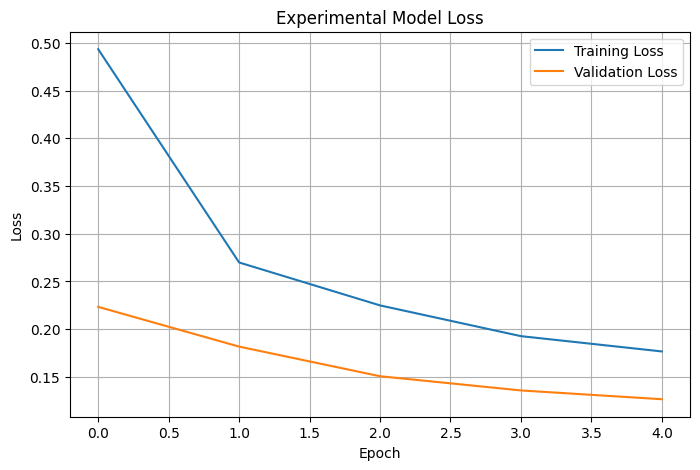

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    experiment_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    experiment_history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Experimental Model Loss')
plt.legend()
plt.grid()
plt.show()